In [17]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt



In [18]:
dataset_path = Path("dataset_ml_structured.csv")
if not dataset_path.exists():
    dataset_path = Path("datasets") / "dataset_ml_structured.csv"

df = pd.read_csv(dataset_path)
print(f"Loaded {dataset_path} with shape {df.shape}")


Loaded dataset_ml_structured.csv with shape (4018, 64)


In [19]:
df.head()

,target_business_type_id,target_business_type,osm_id,feature_has_name,feature_has_house_number,feature_has_street,feature_has_suburb,feature_has_city,feature_has_postcode,feature_has_any_address,...,feature_landuse_retail_500m_zscore,feature_landuse_mixed_500m_zscore,feature_landuse_farmland_500m_zscore,feature_landuse_other_500m_zscore,feature_same_category_ratio_500m_zscore,feature_same_subcategory_ratio_500m_zscore,feature_major_road_ratio_500m_zscore,feature_service_to_poi_ratio_500m_zscore,feature_transport_to_poi_ratio_500m_zscore,feature_road_to_poi_ratio_500m_zscore
0,0,amenity_other,244513191.0,1,0,0,0,0,0,0,...,-0.04995,0.0,-0.18134,-0.229655,1.289075,2.522139,-0.792556,0.941697,-0.522522,-0.021145
1,0,amenity_other,246761183.0,1,0,0,0,0,0,0,...,-0.04995,0.0,-0.18134,-0.229655,0.329426,-0.546305,1.392364,-0.111635,0.105030,-0.419480
2,0,amenity_other,247177690.0,1,0,1,0,0,1,1,...,-0.04995,0.0,-0.18134,-0.229655,0.122617,-0.427373,0.209600,-0.498673,-0.006048,-0.494414
3,0,amenity_other,247177691.0,1,0,0,0,0,0,0,...,-0.04995,0.0,-0.18134,-0.229655,0.348618,0.348658,-0.257577,-0.284118,-0.180855,-0.424433
4,9,hospital,247177822.0,1,0,0,0,0,0,0,...,-0.04995,0.0,-0.18134,-0.229655,1.289075,-0.546305,-0.635097,0.941697,-0.522522,0.110244


In [20]:
print(df.columns)

Index(['target_business_type_id', 'target_business_type', 'osm_id',
       'feature_has_name', 'feature_has_house_number', 'feature_has_street',
       'feature_has_suburb', 'feature_has_city', 'feature_has_postcode',
       'feature_has_any_address', 'feature_osm_type_node',
       'feature_osm_type_relation', 'feature_osm_type_way',
       'feature_category_amenity', 'feature_category_craft',
       'feature_category_healthcare', 'feature_category_office',
       'feature_category_shop', 'feature_lat', 'feature_lon',
       'feature_pois_500m', 'feature_same_category_500m',
       'feature_same_subcategory_500m', 'feature_unique_subcategory_500m',
       'feature_services_500m', 'feature_transport_500m', 'feature_roads_500m',
       'feature_major_roads_500m', 'feature_landuse_residential_500m',
       'feature_landuse_commercial_500m', 'feature_landuse_industrial_500m',
       'feature_landuse_retail_500m', 'feature_landuse_mixed_500m',
       'feature_landuse_farmland_500m', 'featu

In [21]:
df = df.drop(columns=["osm_id"])


In [22]:
feature_cols = [col for col in df.columns if col.startswith("feature_")]

X = df[feature_cols]
y = df["target_business_type_id"]
target_names = (
    df[["target_business_type_id", "target_business_type"]]
    .drop_duplicates()
    .sort_values("target_business_type_id")["target_business_type"]
    .tolist()
)


In [23]:
# y is already encoded as target_business_type_id in the preprocessed dataset.
print(f"Classes: {len(target_names)}")
print(target_names)


Classes: 18
['amenity_other', 'cafe', 'cake_shop', 'clinic', 'electronics', 'fast_food', 'furniture', 'grocery', 'healthcare_other', 'hospital', 'ice_cream', 'marketplace', 'meat_shop', 'mechanic_shop', 'restaurant', 'retail_other', 'services_other', 'supermarket']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [26]:
model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs"
)

model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [27]:
y_pred = model.predict(X_test)


In [28]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.486318407960199


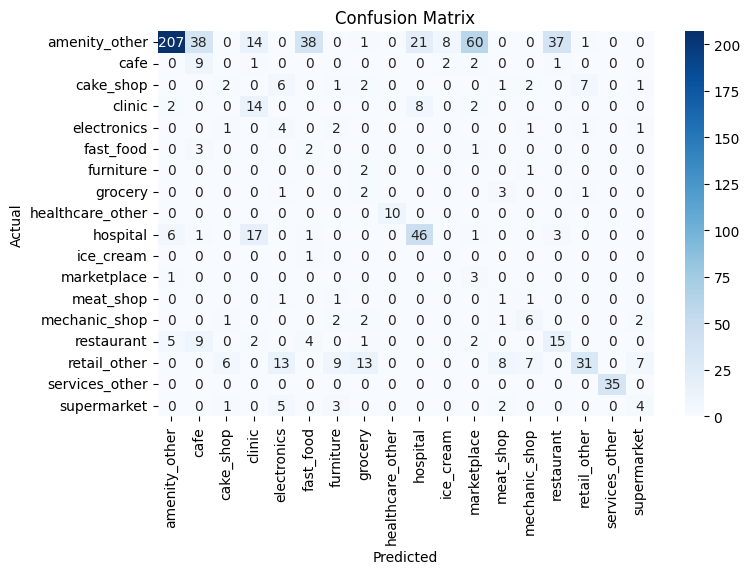

In [33]:
plt.figure(figsize=(8,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [34]:
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


                  precision    recall  f1-score   support

   amenity_other       0.94      0.49      0.64       425
            cafe       0.15      0.60      0.24        15
       cake_shop       0.18      0.09      0.12        22
          clinic       0.29      0.54      0.38        26
     electronics       0.13      0.40      0.20        10
       fast_food       0.04      0.33      0.08         6
       furniture       0.00      0.00      0.00         3
         grocery       0.09      0.29      0.13         7
healthcare_other       1.00      1.00      1.00        10
        hospital       0.61      0.61      0.61        75
       ice_cream       0.00      0.00      0.00         1
     marketplace       0.04      0.75      0.08         4
       meat_shop       0.06      0.25      0.10         4
   mechanic_shop       0.33      0.43      0.38        14
      restaurant       0.27      0.39      0.32        38
    retail_other       0.76      0.33      0.46        94
  services_ot